In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visuals
sns.set(style="whitegrid")

# Load your combined data
# Adjust the path if your notebook is in the 'notebooks' folder
df = pd.read_csv('../data/processed/Si_ML_ready_clean.csv') 

# Quick check to ensure columns like Si_frac and O_frac are there
print(df.columns)

Index(['Synthesizable', 'Material ID', 'Formula', 'Crystal System',
       'Space Group Symbol', 'Space Group Number', 'Sites',
       'Energy Above Hull', 'Formation Energy', 'Predicted Stable', 'Volume',
       'Density', 'Band Gap', 'Is Gap Direct', 'Is Metal', 'Magnetic Ordering',
       'Total Magnetization', 'Bulk Modulus, Voigt', 'Bulk Modulus, Reuss',
       'Bulk Modulus, VRH', 'Shear Modulus, Voigt', 'Shear Modulus, Reuss',
       'Shear Modulus, VRH', 'Elastic Anisotropy', 'Weighted Surface Energy',
       'Surface Anisotropy', 'Shape Factor', 'Work Function',
       'Piezoelectric Modulus', 'Total Dielectric Constant',
       'Ionic Dielectric Constant', 'Static Dielectric Constant', 'Si_frac',
       'O_frac', 'C_frac', 'N_frac'],
      dtype='object')


In [3]:
# 1. Filter for pure SiO2
# Stoichiometrically, SiO2 is 33.3% Si and 66.6% O
sio2_df = df[
    (df['Si_frac'] > 0.3) & 
    (df['O_frac'] > 0.6) & 
    (df['C_frac'] == 0) & 
    (df['N_frac'] == 0)
].copy()

print(f"Number of SiO2 polymorphs isolated: {len(sio2_df)}")

Number of SiO2 polymorphs isolated: 330


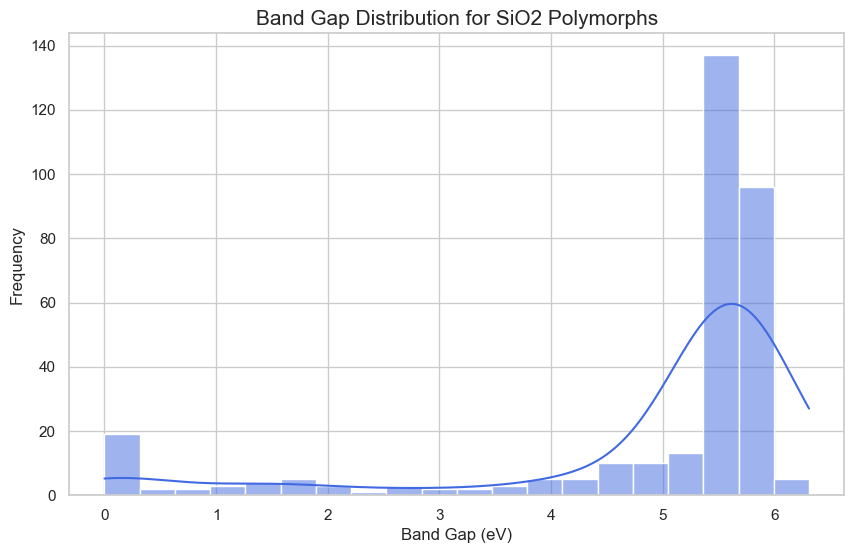

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(sio2_df['Band Gap'], bins=20, kde=True, color='royalblue')
plt.title(f"Band Gap Distribution for SiO2 Polymorphs", fontsize=15)
plt.xlabel("Band Gap (eV)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()

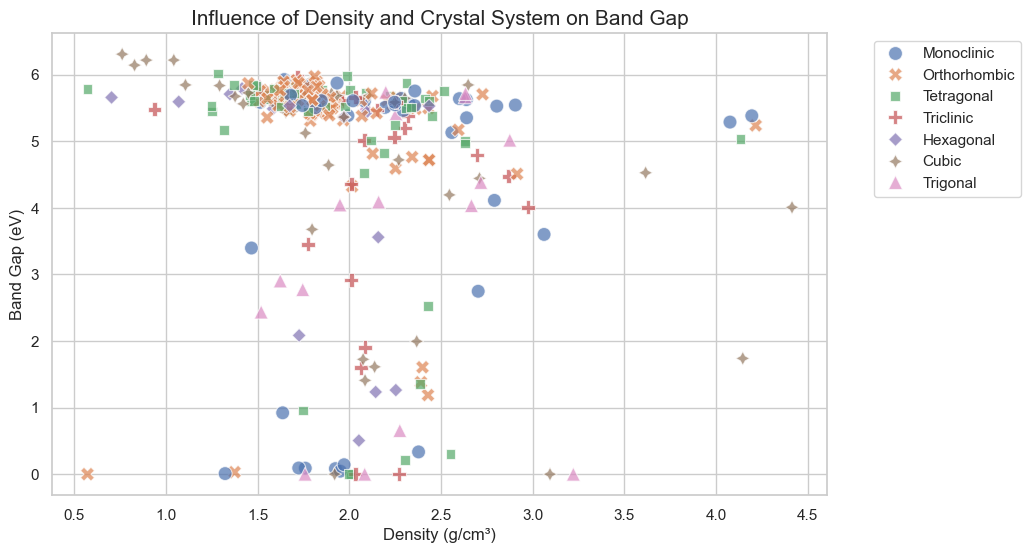

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sio2_df, x='Density', y='Band Gap', hue='Crystal System', style='Crystal System', s=100, alpha=0.7)
plt.title("Influence of Density and Crystal System on Band Gap", fontsize=15)
plt.xlabel("Density (g/cm³)", fontsize=12)
plt.ylabel("Band Gap (eV)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

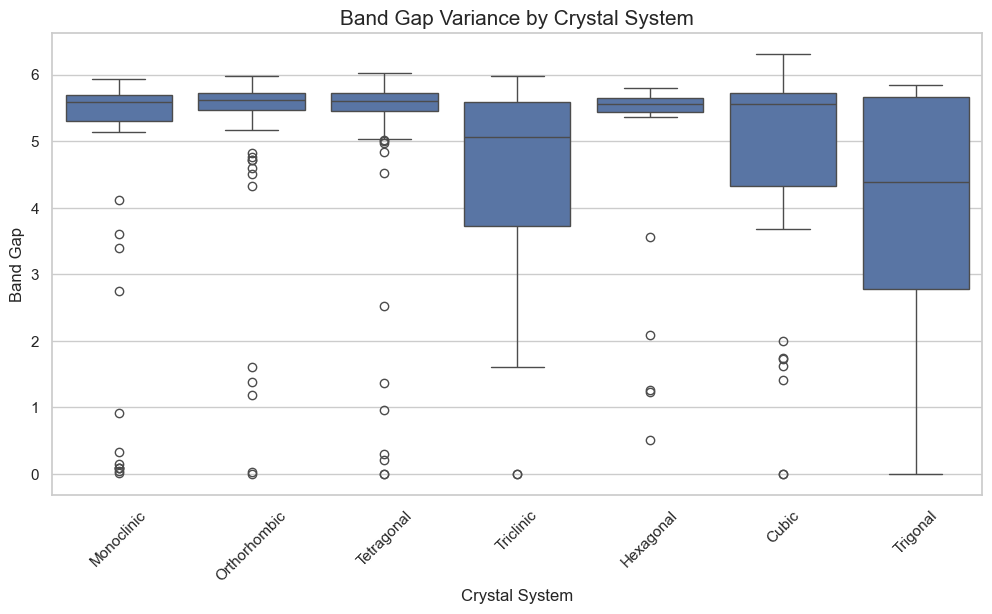

In [6]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=sio2_df, x='Crystal System', y='Band Gap')
plt.title("Band Gap Variance by Crystal System", fontsize=15)
plt.xticks(rotation=45)
plt.show()

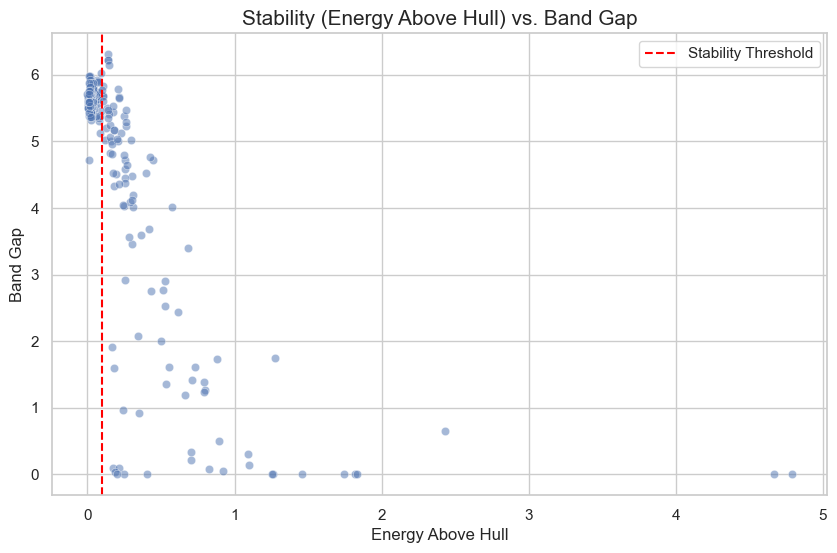

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=sio2_df, x='Energy Above Hull', y='Band Gap', alpha=0.5)
plt.axvline(x=0.1, color='red', linestyle='--', label='Stability Threshold')
plt.title("Stability (Energy Above Hull) vs. Band Gap", fontsize=15)
plt.legend()
plt.show()

In [8]:
# We look for the high-density (compressed) structures with low band gaps
exception_group = sio2_df[sio2_df['Density'] > 3.0].sort_values('Band Gap')

print("--- The 'Compressed' Exception Group ---")
print(exception_group[['Material ID', 'Crystal System', 'Density', 'Band Gap']].head())

--- The 'Compressed' Exception Group ---
    Material ID Crystal System   Density  Band Gap
324   mp-638035       Trigonal  3.222079    0.0000
326   mp-638049          Cubic  3.094818    0.0000
62     mp-10064          Cubic  4.146372    1.7396
123   mp-553881     Monoclinic  3.062424    3.6020
379     mp-9258          Cubic  4.415009    4.0091
